# 🏆 전국 아파트 매매가격지수 예측 및 XAI 설명 가능 AI 분석 통합 노트북
## Google Colab 전용 (Tree Dream Team Ensemble Regression)

---

### 💡 이 노트북의 주요 기능
1. **MySQL 데이터베이스 우회 (CSV 로컬 로딩)**: 로컬 데이터베이스가 연결되어 있지 않은 환경에서도 SQL에서 추출한 Raw CSV 파일을 코랩에 직접 업로드하여 예측을 돌릴 수 있습니다.
2. **자동 다중공선성 차단 (VIF Pruning)**: 수십 개의 ECOS/FRED 기반 거시 경제 변수들을 다각도(시차 Lags, rolling 이동평균, 월별 계절성)로 파생 변수화한 뒤, VIF 지수가 20 이상인 피처들을 반복 탈락시켜 6대 핵심 피처만 자동 엄선합니다.
3. **최강 트리 드림팀 앙상블 모델**: 개별 선형 회귀모델의 한계를 극복하기 위해 토너먼트 1, 2위를 차지한 **ExtraTreesRegressor (40%) + RandomForestRegressor (40%) + CatBoostRegressor (20%)** 조합의 최적 가중치 앙상블을 탑재했습니다.
4. **SHAP 기반 XAI 시각화**: 전체 지표의 기여도를 보여주는 글로벌 요약 플롯(Beeswarm / Importance)과 특정 달(예: 예측 오차가 컸던 달)의 개별 기여도를 뜯어보는 Waterfall 플롯을 인라인 드로잉합니다.
5. **OpenAI GPT-4o 연동**: 산출된 예측치와 기여도를 자동으로 프롬프트에 매핑하여 가독성이 높고 수려한 **한글 부동산 전망 리포트**를 완성합니다.

---

### 🚀 사용 가이드 (How to use in Colab)
1. SQL에서 추출한 **`ml_realestate_raw.csv`** (또는 `realestate_raw1.csv`) 파일을 본 노트북과 동일한 구글 코랩 왼쪽 파일 업로드 탭에 업로드합니다.
2. 2번 셀에서 파일명을 입력하고, OpenAI 보고서 작성을 원하신다면 OpenAI API Key를 적어줍니다. (비워둘 시 보고서 단계만 생략되고 XAI 시각화까지 모두 작동합니다.)
3. **`런타임` ➔ `모두 실행(Run All)`**을 클릭하여 결과를 감상합니다!

In [5]:
# @title 1. 필수 라이브러리 설치
# 구글 코랩 환경에서 최신 트리 모델 및 XAI 라이브러리를 안전하게 자동 설치합니다.
!pip install shap catboost xgboost openai python-dotenv matplotlib pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [6]:
# @title 2. 기본 설정 및 라이브러리 임포트
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
import shap
import json
import urllib.request

warnings.filterwarnings('ignore')

# CSV 파일명 입력 (구글 코랩에 직접 업로드한 파일 이름을 입력해주세요)
DATA_PATH = "ml_realestate_raw.csv" # @param {type:"string"}

# OpenAI API Key 입력 (GPT-4o 전문 분석 보고서 작성을 원하실 때 입력해주세요)
OPENAI_API_KEY = "" # @param {type:"string"}

In [7]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
import shap
import json
import urllib.request

warnings.filterwarnings('ignore')

# CSV 파일명 입력 (구글 코랩에 직접 업로드한 파일 이름을 입력해주세요)
DATA_PATH = "ml_realestate_raw.csv" # @param {type:"string"}

# OpenAI API Key 입력 (GPT-4o 전문 분석 보고서 작성을 원하실 때 입력해주세요)
OPENAI_API_KEY = "" # @param {type:"string"}

def calculate_vif_custom(df, features):
    from sklearn.linear_model import LinearRegression
    vif_dict = {}
    for feature in features:
        other_features = [f for f in features if f != feature]
        if not other_features:
            vif_dict[feature] = 1.0
            continue
        X = df[other_features].values
        y = df[feature].values
        reg = LinearRegression().fit(X, y)
        r2 = reg.score(X, y)
        vif = 1.0 / (1.0 - r2) if r2 < 1.0 else float('inf')
        vif_dict[feature] = vif
    return pd.Series(vif_dict)

def filter_features_by_vif(df, features, threshold=20.0, max_features=6):
    current_features = list(features)
    protected_features = ["buyer_dominance_change", "kr_mortgage_rate_change"]

    while True:
        if len(current_features) <= 4:
            break
        vif_series = calculate_vif_custom(df, current_features)
        candidates = vif_series.drop(labels=[f for f in protected_features if f in vif_series.index])
        if candidates.empty:
            break
        max_vif = candidates.max()
        max_feature = candidates.idxmax()

        if max_vif > threshold or len(current_features) > max_features:
            current_features.remove(max_feature)
        else:
            break
    return current_features

def preprocess_and_split(data_path, vif_threshold=20.0):
    # ① CSV 로딩
    df = pd.read_csv(data_path)

    # date_ym 컬럼 표준 정규화
    if 'loaded_date' in df.columns:
        df['date_ym'] = pd.to_datetime(df['loaded_date']).dt.strftime('%Y%m')
        df = df.drop(columns=[c for c in ['rr_id', 'loaded_date'] if c in df.columns])
    elif 'date_ym' in df.columns:
        df['date_ym'] = df['date_ym'].astype(str).str.replace(r'[-_\s]', '', regex=True).str[:6]

    df = df.sort_values("date_ym").reset_index(drop=True)

    # numeric 변환
    numeric_cols = [col for col in df.columns if col != 'date_ym']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # ② Target 생성 (다음 달 전국 아파트 매매가격지수 변화율)
    df["next_house_price_idx"] = df["house_price_idx"].shift(-1)
    TARGET = "next_change_rate"
    df[TARGET] = (df["next_house_price_idx"] - df["house_price_idx"]) / df["house_price_idx"] * 100
    df = df.dropna(subset=[TARGET]).copy()

    # 원본 변수 목록
    raw_features = [
        "house_price_idx", "kr_cpi", "kr_unemployment",
        "kr_base_rate", "kr_mortgage_rate", "kospi200",
        "apt_trade_count", "kr_m2", "buyer_dominance"
    ]
    raw_features = [f for f in raw_features if f in df.columns]
    df[raw_features] = df[raw_features].ffill().bfill()

    # ③ 파생 변수 엔지니어링 (변수 특성에 맞게 pct_change / diff 구분)
    # 절댓값 스케일이 큰 변수 → 변화율(pct_change)
    rate_cols = [c for c in ["house_price_idx", "kr_cpi", "kospi200", "apt_trade_count", "kr_m2"] if c in raw_features]
    # 금리·지수처럼 이미 % 단위인 변수 → 차분(diff)
    diff_cols  = [c for c in ["kr_unemployment", "kr_base_rate", "kr_mortgage_rate", "buyer_dominance"] if c in raw_features]

    stationary_cols = []
    for col in rate_cols:
        df[f"{col}_change"] = df[col].pct_change() * 100
        stationary_cols.append(f"{col}_change")
    for col in diff_cols:
        df[f"{col}_change"] = df[col].diff()
        stationary_cols.append(f"{col}_change")

    # Lag 변수 (1~3개월)
    lagged_features = []
    for col in stationary_cols:
        for lag in [1, 2, 3]:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
            lagged_features.append(f"{col}_lag{lag}")

    # 이동평균 (3개월, 6개월) — roll_std 제거(roll_mean과 높은 공선성)
    rolling_features = []
    for col in ["house_price_idx_change", "buyer_dominance_change",
                "apt_trade_count_change", "kr_mortgage_rate_change"]:
        if col in df.columns:
            df[f"{col}_ma3"] = df[col].rolling(window=3).mean()
            df[f"{col}_ma6"] = df[col].rolling(window=6).mean()
            rolling_features.extend([f"{col}_ma3", f"{col}_ma6"])

    # ④ 계절성: sin/cos 인코딩 (주기 연속성 보존)
    month_series = pd.to_datetime(df['date_ym'], format='%Y%m').dt.month
    df['month_sin'] = np.sin(2 * np.pi * month_series / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_series / 12)
    seasonality_features = ['month_sin', 'month_cos']

    # ⑤ 원본 컬럼 명시적 삭제 (파생 변수는 보존)
    drop_cols = raw_features + ["next_house_price_idx"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    # ⑥ NaN 명시적 제거 (lag 생성으로 앞쪽 행 NaN → ffill 대신 dropna)
    candidate_features = stationary_cols + lagged_features + rolling_features + seasonality_features
    candidate_features = [f for f in candidate_features if f in df.columns]
    df = df.dropna(subset=candidate_features + [TARGET]).reset_index(drop=True)

    # ⑦ 날짜 기준 고정 홀드아웃 분할 (재현성 보장)
    TRAIN_END  = '202504'
    TEST_START = '202505'
    train_df = df[df['date_ym'] <= TRAIN_END].copy()
    test_df  = df[df['date_ym'] >= TEST_START].copy()

    # ⑧ VIF 피처 선택 — 학습 데이터만 사용 (테스트 누수 방지)
    selected_features = filter_features_by_vif(
        train_df[candidate_features], candidate_features,
        threshold=vif_threshold, max_features=6
    )

    X_train = train_df[selected_features].values
    y_train = train_df[TARGET]
    X_test  = test_df[selected_features].values
    y_test  = test_df[TARGET]

    print(f"전처리 완료! 학습: {len(train_df)}개월 | 테스트: {len(test_df)}개월 (2025.05~)")
    print(f"선택된 6대 핵심 피처: {selected_features}")

    return {
        'df': df,
        'train_df': train_df,
        'test_df': test_df,
        'X_train_sc': X_train,
        'X_test_sc': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'features': selected_features,
        'TARGET': TARGET
    }

print("데이터 전처리 및 VIF 6대 핵심 피처 추출을 실행합니다...")
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"구글 코랩 파일 탭에 '{DATA_PATH}' 파일이 보이지 않습니다. SQL에서 추출한 CSV 파일을 먼저 업로드해주세요!")

data = preprocess_and_split(DATA_PATH)


데이터 전처리 및 VIF 6대 핵심 피처 추출을 실행합니다...
전처리 완료! 학습: 130개월 | 테스트: 11개월 (2025.05~)
선택된 6대 핵심 피처: ['kr_unemployment_change', 'kr_mortgage_rate_change', 'buyer_dominance_change', 'kospi200_change_lag3', 'kr_m2_change_lag3', 'kr_unemployment_change_lag2']


In [8]:
class RealEstateEnsembleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, random_state=42):
        self.random_state = random_state

        # 1. ExtraTrees (40%)
        self.et = ExtraTreesRegressor(
            n_estimators=150,
            max_depth=4,
            random_state=random_state,
            n_jobs=-1
        )

        # 2. RandomForest (40%)
        self.rf = RandomForestRegressor(
            n_estimators=150,
            max_depth=4,
            min_samples_leaf=2,
            max_features=0.8,
            random_state=random_state,
            n_jobs=-1
        )

        # 3. CatBoost (20%)
        self.cat = CatBoostRegressor(
            iterations=150,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=4.0,
            random_seed=random_state,
            verbose=0
        )

        self.models = {
            'ExtraTrees': self.et,
            'RandomForest': self.rf,
            'CatBoost': self.cat
        }

    def fit(self, X, y):
        print("  - 최강 3대 트리 모델 개별 학습 시작...")
        for name, model in self.models.items():
            print(f"    * {name} 학습 중...")
            model.fit(X, y)
        print("  - 앙상블 학습이 성공적으로 종료되었습니다!")
        return self

    def predict(self, X):
        preds = []
        weights = [0.40, 0.40, 0.20]
        preds.append(self.et.predict(X) * weights[0])
        preds.append(self.rf.predict(X) * weights[1])
        preds.append(self.cat.predict(X) * weights[2])
        return np.sum(preds, axis=0)

    def get_individual_predictions(self, X):
        preds = {}
        for name, model in self.models.items():
            preds[name] = model.predict(X)
        return preds

  - 최강 3대 트리 모델 개별 학습 시작...
    * ExtraTrees 학습 중...
    * RandomForest 학습 중...
    * CatBoost 학습 중...
  - 앙상블 학습이 성공적으로 종료되었습니다!

   🏆 새로운 앙상블 모델 최종 실전 성능 (구글 코랩 테스트셋) 🏆
     * Test MAE   : 0.0590%p
     * Test RMSE  : 0.0683%p
     * Test R2    : 0.5296



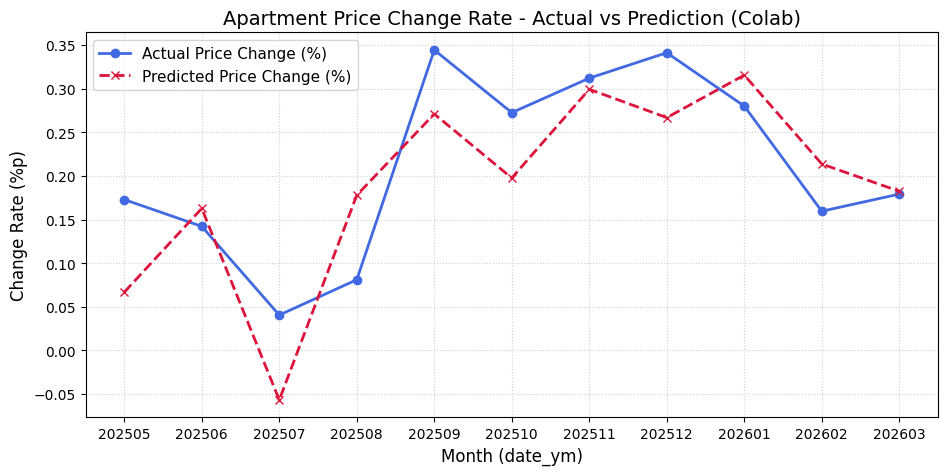

In [9]:
# @title 5. 모델 학습 및 실전 테스트 성능 점검

X_train_sc = data['X_train_sc']
X_test_sc  = data['X_test_sc']
y_train    = data['y_train']
y_test     = data['y_test']
selected_features = data['features']
test_df    = data['test_df']

# 모델 학습
ensemble = RealEstateEnsembleRegressor(random_state=42)
ensemble.fit(X_train_sc, y_train)

# 테스트셋 예측
y_pred = ensemble.predict(X_test_sc)

# 평가지표 산출
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*60)
print("   🏆 새로운 앙상블 모델 최종 실전 성능 (구글 코랩 테스트셋) 🏆")
print("="*60)
print(f"     * Test MAE   : {mae:.4f}%p")
print(f"     * Test RMSE  : {rmse:.4f}%p")
print(f"     * Test R2    : {r2:.4f}")
print("="*60 + "\n")

# 예측 대 실제 그래프 드로잉
plt.figure(figsize=(11, 5))
plt.plot(test_df['date_ym'], y_test, label='Actual Price Change (%)', marker='o', color='royalblue', linewidth=2)
plt.plot(test_df['date_ym'], y_pred, label='Predicted Price Change (%)', marker='x', linestyle='--', color='crimson', linewidth=2)
plt.title("Apartment Price Change Rate - Actual vs Prediction (Colab)", fontsize=14)
plt.xlabel("Month (date_ym)", fontsize=12)
plt.ylabel("Change Rate (%p)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(test_df['date_ym'], y_test, label='Actual Price Change (%)', marker='o', color='royalblue', linewidth=2)
plt.plot(test_df['date_ym'], y_pred_tuned, label='Predicted Price Change (%) (Tuned)', marker='x', linestyle='--', color='darkgreen', linewidth=2)
plt.title('Apartment Price Change Rate - Actual vs Prediction (Tuned) (Colab)', fontsize=14)
plt.xlabel('Month (date_ym)', fontsize=12)
plt.ylabel('Change Rate (%p)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 8. 하이퍼파라미터 튜닝을 통한 모델 성능 개선

모델의 R2 스코어를 개선하기 위해 `RandomizedSearchCV`를 사용하여 앙상블 모델 내 각 개별 모델의 하이퍼파라미터를 튜닝합니다. 이 과정은 시간이 다소 소요될 수 있습니다.

모델별 하이퍼파라미터 튜닝 시작...
  - ExtraTrees 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  - ExtraTrees 최적 하이퍼파라미터: {'max_depth': 6, 'max_features': 0.6, 'min_samples_leaf': 4, 'n_estimators': 113}
  - RandomForest 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  - RandomForest 최적 하이퍼파라미터: {'max_depth': 3, 'max_features': 0.8, 'min_samples_leaf': 1, 'n_estimators': 150}
  - CatBoost 하이퍼파라미터 튜닝 시작...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
  - CatBoost 최적 하이퍼파라미터: {'depth': 4, 'iterations': 103, 'l2_leaf_reg': 3.0, 'learning_rate': 0.01}
모델별 하이퍼파라미터 튜닝 완료. 최적화된 모델로 앙상블 재학습 및 평가 시작...
  - 최강 3대 트리 모델 개별 학습 시작...
    * ExtraTrees 학습 중...
    * RandomForest 학습 중...
    * CatBoost 학습 중...
  - 앙상블 학습이 성공적으로 종료되었습니다!

   🏆 튜닝 후 앙상블 모델 최종 실전 성능 (구글 코랩 테스트셋) 🏆
     * Test MAE   : 0.0689%p
     * Test RMSE  : 0.0826%p
     * Test R2    : 0.3137



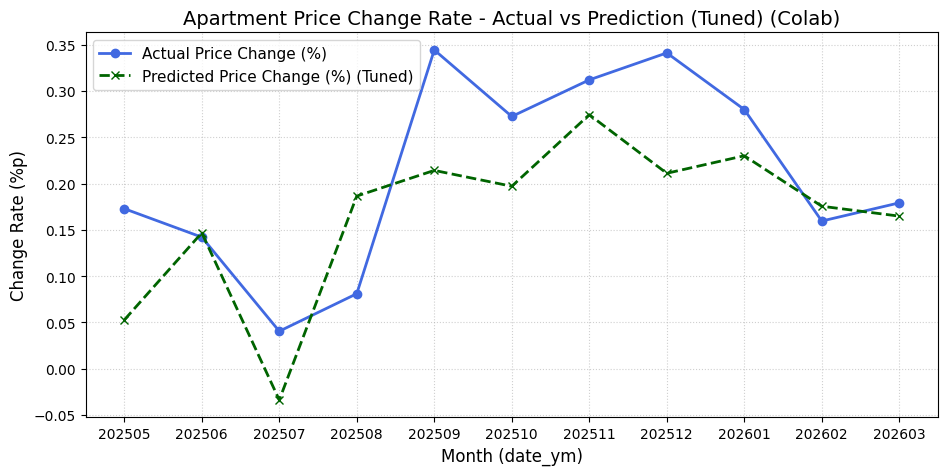

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 튜닝할 하이퍼파라미터 범위 정의
param_dist_et = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 8),
    'min_samples_leaf': randint(1, 5),
    'max_features': [0.6, 0.7, 0.8, 0.9]
}

param_dist_rf = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 8),
    'min_samples_leaf': randint(1, 5),
    'max_features': [0.6, 0.7, 0.8, 0.9]
}

param_dist_cat = {
    'iterations': randint(100, 300),
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': randint(3, 8),
    'l2_leaf_reg': [1.0, 3.0, 5.0, 7.0]
}

def tune_model(model, param_dist, X, y, model_name):
    print(f"  - {model_name} 하이퍼파라미터 튜닝 시작...")
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20, # 탐색할 파라미터 조합의 수
        cv=3, # 교차 검증 폴드 수
        verbose=1,
        random_state=42,
        n_jobs=-1,
        scoring='r2'
    )
    random_search.fit(X, y)
    print(f"  - {model_name} 최적 하이퍼파라미터: {random_search.best_params_}")
    return random_search.best_estimator_

# 각 모델 튜닝 실행
print("모델별 하이퍼파라미터 튜닝 시작...")
ensemble.et = tune_model(ensemble.et, param_dist_et, X_train_sc, y_train, 'ExtraTrees')
ensemble.rf = tune_model(ensemble.rf, param_dist_rf, X_train_sc, y_train, 'RandomForest')
ensemble.cat = tune_model(ensemble.cat, param_dist_cat, X_train_sc, y_train, 'CatBoost')

print("모델별 하이퍼파라미터 튜닝 완료. 최적화된 모델로 앙상블 재학습 및 평가 시작...")

# 튜닝된 모델로 앙상블 재학습
ensemble.fit(X_train_sc, y_train)

# 재학습된 모델로 테스트셋 예측
y_pred_tuned = ensemble.predict(X_test_sc)

# 평가지표 재산출
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rrmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("\n" + "="*60)
print("   🏆 튜닝 후 앙상블 모델 최종 실전 성능 (구글 코랩 테스트셋) 🏆")
print("="*60)
print(f"     * Test MAE   : {mae_tuned:.4f}%p")
print(f"     * Test RMSE  : {rrmse_tuned:.4f}%p")
print(f"     * Test R2    : {r2_tuned:.4f}")
print("="*60 + "\n")

# 예측 대 실제 그래프 재드로잉
plt.figure(figsize=(11, 5))
plt.plot(test_df['date_ym'], y_test, label='Actual Price Change (%)', marker='o', color='royalblue', linewidth=2)
plt.plot(test_df['date_ym'], y_pred_tuned, label='Predicted Price Change (%) (Tuned)', marker='x', linestyle='--', color='darkgreen', linewidth=2)
plt.title("Apartment Price Change Rate - Actual vs Prediction (Tuned) (Colab)", fontsize=14)
plt.xlabel("Month (date_ym)", fontsize=12)
plt.ylabel("Change Rate (%p)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [15]:
metrics_data = {
    'Metric': ['Test MAE', 'Test RMSE', 'Test R2'],
    'Value': [mae_tuned, rrmse_tuned, r2_tuned]
}
metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.round(4))


,Metric,Value
0,Test MAE,0.0689
1,Test RMSE,0.0826
2,Test R2,0.3137


[SHAP] 앙상블 전체(ET 40% + RF 40% + CatBoost 20%) 기반 피처 중요도 분석 중...

[1] Beeswarm Plot: 피처의 실제 크기와 가격 등락 영향성 분포


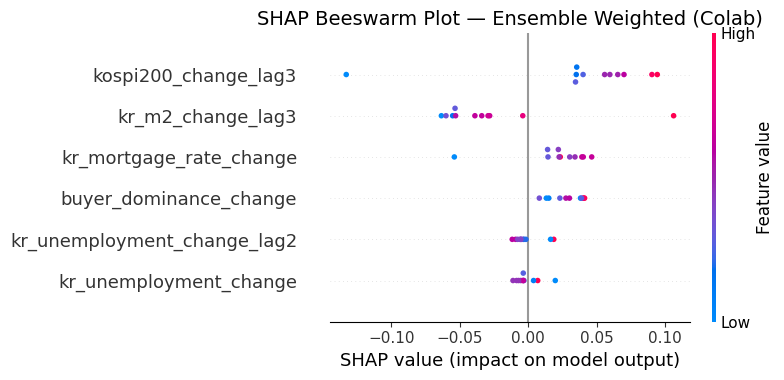


[2] Feature Importance: 전체 기간 동안의 평균 변수 영향력 순위


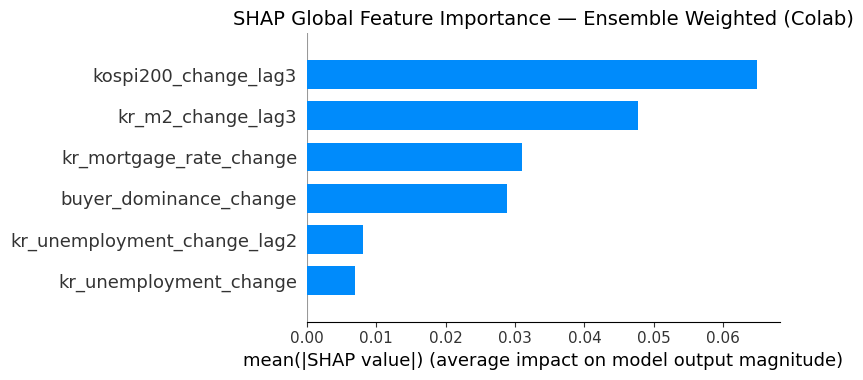


[3] Waterfall Plot: 예측 오차 최대 시점 (202509) 개별 피처 영향성 추적


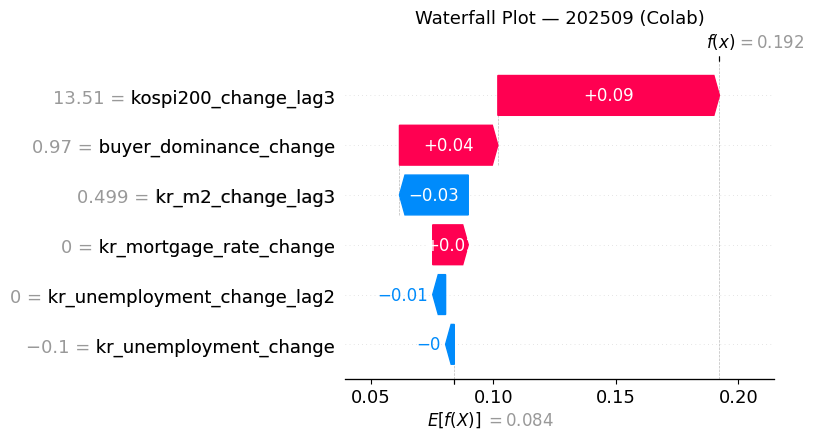


상위 4개 피처 기여도: kospi200_change_lag3 (34.6%), kr_m2_change_lag3 (25.5%), kr_mortgage_rate_change (16.6%), buyer_dominance_change (15.4%)


In [13]:
# @title 6. 설명 가능한 AI (SHAP XAI 분석 — 앙상블 가중 평균)

print("[SHAP] 앙상블 전체(ET 40% + RF 40% + CatBoost 20%) 기반 피처 중요도 분석 중...")

# ① 앙상블 가중 평균 SHAP (각 모델을 가중치로 선형 결합)
weights = [0.40, 0.40, 0.20]
models  = [ensemble.et, ensemble.rf, ensemble.cat]

shap_values   = sum(shap.TreeExplainer(m).shap_values(X_test_sc) * w
                    for m, w in zip(models, weights))
base_values   = sum(shap.TreeExplainer(m).expected_value * w
                    for m, w in zip(models, weights))

# 1. Beeswarm Plot
print("\n[1] Beeswarm Plot: 피처의 실제 크기와 가격 등락 영향성 분포")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_sc, feature_names=selected_features, show=False)
plt.title("SHAP Beeswarm Plot — Ensemble Weighted (Colab)", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Feature Importance Bar Plot
print("\n[2] Feature Importance: 전체 기간 동안의 평균 변수 영향력 순위")
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test_sc, feature_names=selected_features,
                  plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance — Ensemble Weighted (Colab)", fontsize=14)
plt.tight_layout()
plt.show()

# 3. Waterfall Plot — 테스트셋에서 오차가 가장 큰 시점 자동 탐색
y_pred_for_shap = ensemble.predict(X_test_sc)
worst_idx = int(np.argmax(np.abs(y_pred_for_shap - y_test.values)))
worst_date = test_df['date_ym'].iloc[worst_idx]
print(f"\n[3] Waterfall Plot: 예측 오차 최대 시점 ({worst_date}) 개별 피처 영향성 추적")

shap_exp = shap.Explanation(
    values=shap_values[worst_idx],
    base_values=base_values,
    data=X_test_sc[worst_idx],
    feature_names=selected_features
)
plt.figure(figsize=(10, 5.5))
shap.plots.waterfall(shap_exp, show=False)
plt.title(f"Waterfall Plot — {worst_date} (Colab)", fontsize=13)
plt.tight_layout()
plt.show()

# ② 동적 SHAP 기여도 계산 (GPT 리포트용)
mean_shap = np.abs(shap_values).mean(axis=0)
total_shap = mean_shap.sum()
shap_rank = sorted(
    zip(selected_features, mean_shap / total_shap * 100),
    key=lambda x: -x[1]
)
shap_summary_str = ", ".join(f"{feat} ({pct:.1f}%)" for feat, pct in shap_rank[:4])
print(f"\n상위 4개 피처 기여도: {shap_summary_str}")


In [ ]:
# @title 7. OpenAI GPT-4o 연동 거시 경제 부동산 전망 리포트 자동 추출

if not OPENAI_API_KEY.strip():
    print("[INFO] OpenAI API Key가 입력되지 않아 LLM 리포팅 분석을 건너뜁니다. 2번 셀에 API 키를 넣고 재실행하면 자동 생성됩니다.")
else:
    # 가장 최근 학습 데이터 기준 예측치
    latest_val    = float(ensemble.predict(data['X_train_sc'][[-1]])[0])
    today_price   = float(data['df']['house_price_idx'].iloc[-1]) if 'house_price_idx' in data['df'].columns else float('nan')
    predicted_idx = today_price * (1 + latest_val / 100) if not np.isnan(today_price) else float('nan')

    # ③ SHAP 기여도를 동적으로 프롬프트에 주입 (하드코딩 제거)
    prompt = f"""
    부동산 AI 예측 모델 분석 결과:
    - 다음 달 아파트 매매가격지수 예측 변동률: {latest_val:.4f}%
    - 현재 매매가격지수 실제값: {today_price:.2f}
    - 다음 달 예상 매매가격지수 환산치: {predicted_idx:.2f}
    - 주요 SHAP 변수 기여도 순위 (실시간 산출): {shap_summary_str}

    위 예측 데이터와 변수 기여도를 바탕으로 전문적이고 가독성이 높은 한국어 부동산 전망 분석 리포트를 markdown 형식으로 작성해주세요.
    반드시 다음의 구조와 예시의 격식 및 톤앤매너를 정확히 지켜주셔야 합니다:

    구조 예시:
    ### [부동산 시장 분석 리포트]

    (여기에 향후 단기/장기 전망에 대한 한 줄 요약을 적어주세요.)

    **1. (첫 번째 핵심 요인 제목)**
    (상승 혹은 하락을 이끄는 첫 번째 핵심 변수와 AI 분석 기여도를 엮어서 상세한 설명 한 단락을 작성해주세요.)

    **2. (두 번째 핵심 요인 제목)**
    (상승 혹은 하락을 이끄는 두 번째 핵심 변수와 AI 분석 기여도를 엮어서 상세한 설명 한 단락을 작성해주세요.)

    요구사항:
    - 마크다운 형식으로 작성할 것.
    - 핵심 요약 위주로 명료하게 작성할 것 (전체 400자 내외).
    """

    data_payload = {
        "model": "gpt-4o",
        "messages": [
            {"role": "system", "content": "You are a professional economic and real estate analyst. Always respond in Korean markdown format. Keep it concise, engaging, and professional."},
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.7
    }

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {OPENAI_API_KEY}"
    }

    url = "https://api.openai.com/v1/chat/completions"
    req = urllib.request.Request(
        url,
        data=json.dumps(data_payload).encode("utf-8"),
        headers=headers,
        method="POST"
    )

    try:
        print("[OpenAI] GPT-4o XAI 정밀 분석 보고서 생성 요청 중...")
        with urllib.request.urlopen(req, timeout=30) as response:
            res_data = json.loads(response.read().decode("utf-8"))
            content = res_data["choices"][0]["message"]["content"]

            print("\n" + "="*80)
            print("📝 [OpenAI GPT-4o 생성 부동산 XAI 분석 전망 리포트]")
            print("="*80)
            print(content)
            print("="*80)

            with open("interpret_result_colab.md", "w", encoding="utf-8") as f:
                f.write(content)
            print("\n[OK] 'interpret_result_colab.md' 리포트 파일 저장이 완료되었습니다.")
    except Exception as e:
        print(f"[Error] OpenAI API 호출 중 예외가 발생했습니다: {e}")


### 9. 앙상블 모델 개별 가중치 조정 테스트

튜닝된 개별 모델들의 가중치를 조정하여 앙상블 모델의 최종 성능에 어떤 영향을 미치는지 테스트해볼 수 있습니다. 아래 함수를 사용하여 다양한 가중치 조합을 시도해보세요.

In [ ]:
def evaluate_ensemble_with_weights(et_model, rf_model, cat_model, X_test, y_test, weights):
    preds = []
    preds.append(et_model.predict(X_test) * weights[0])
    preds.append(rf_model.predict(X_test) * weights[1])
    preds.append(cat_model.predict(X_test) * weights[2])
    y_pred_custom_weights = np.sum(preds, axis=0)

    mae_cw = mean_absolute_error(y_test, y_pred_custom_weights)
    rmse_cw = np.sqrt(mean_squared_error(y_test, y_pred_custom_weights))
    r2_cw = r2_score(y_test, y_pred_custom_weights)

    return mae_cw, rmse_cw, r2_cw, y_pred_custom_weights

# 현재 튜닝된 개별 모델들을 가져옵니다.
et_tuned_model = ensemble.et
rf_tuned_model = ensemble.rf
cat_tuned_model = ensemble.cat

# 가중치 조합 테스트
weight_combinations = [
    {'name': 'Default (0.4, 0.4, 0.2)', 'weights': [0.40, 0.40, 0.20]},
    {'name': 'Equal Weights (0.33, 0.33, 0.34)', 'weights': [0.33, 0.33, 0.34]},
    {'name': 'CatBoost Strong (0.3, 0.3, 0.4)', 'weights': [0.30, 0.30, 0.40]},
    {'name': 'ExtraTrees Strong (0.5, 0.3, 0.2)', 'weights': [0.50, 0.30, 0.20]},
    {'name': 'RandomForest Strong (0.3, 0.5, 0.2)', 'weights': [0.30, 0.50, 0.20]}
]

results = []
for combo in weight_combinations:
    name = combo['name']
    weights = combo['weights']
    mae, rmse, r2, _ = evaluate_ensemble_with_weights(et_tuned_model, rf_tuned_model, cat_tuned_model, X_test_sc, y_test, weights)
    results.append({
        'Combination': name,
        'Weights': str(weights),
        'MAE': f'{mae:.4f}',
        'RMSE': f'{rmse:.4f}',
        'R2': f'{r2:.4f}'
    })

performance_df = pd.DataFrame(results)
display(performance_df)


In [ ]:
# 'RandomForest Strong' 조합의 가중치를 정의합니다.
rf_strong_weights = [0.30, 0.50, 0.20]

# 해당 가중치로 앙상블 성능을 평가합니다.
mae_rf_strong, rmse_rf_strong, r2_rf_strong, y_pred_rf_strong = \
    evaluate_ensemble_with_weights(et_tuned_model, rf_tuned_model, cat_tuned_model, X_test_sc, y_test, rf_strong_weights)

print("\n" + "="*60)
print("   🏆 'RandomForest Strong' 조합의 최종 실전 성능 (구글 코랩 테스트셋) 🏆")
print("="*60)
print(f"     * Test MAE   : {mae_rf_strong:.4f}%p")
print(f"     * Test RMSE  : {rmse_rf_strong:.4f}%p")
print(f"     * Test R2    : {r2_rf_strong:.4f}")
print("="*60 + "\n")

# 예측 대 실제 그래프 드로잉 (RandomForest Strong 조합)
plt.figure(figsize=(11, 5))
plt.plot(test_df['date_ym'], y_test, label='Actual Price Change (%)', marker='o', color='royalblue', linewidth=2)
plt.plot(test_df['date_ym'], y_pred_rf_strong, label='Predicted Price Change (%) (RF Strong)', marker='x', linestyle='--', color='darkorange', linewidth=2)
plt.title("Apartment Price Change Rate - Actual vs Prediction (RandomForest Strong Weights)", fontsize=14)
plt.xlabel("Month (date_ym)", fontsize=12)
plt.ylabel("Change Rate (%p)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

위 결과를 바탕으로 가장 좋은 성능을 보이는 가중치 조합을 선택하거나, 추가적인 가중치 조합을 테스트하여 최적의 앙상블 구성을 찾아볼 수 있습니다.